In [112]:
# Polinomial LR

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [113]:
df=pd.read_csv('Position_Salaries.csv')
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [114]:
df.isnull().sum()


Position    0
Level       0
Salary      0
dtype: int64

In [115]:
df.duplicated().sum()


np.int64(0)

<Axes: >

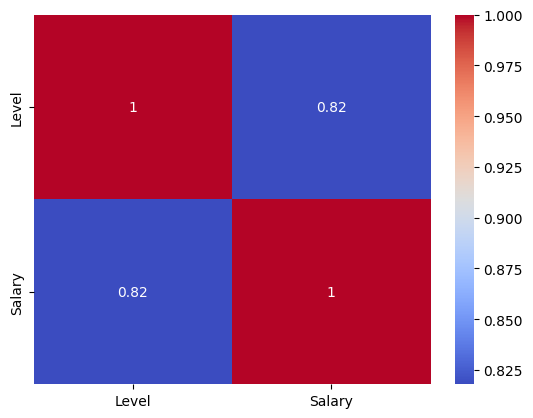

In [116]:

#correlation
cor=df.select_dtypes('number').corr()
sns.heatmap(cor,annot=True,cmap='coolwarm')

<Axes: ylabel='Salary'>

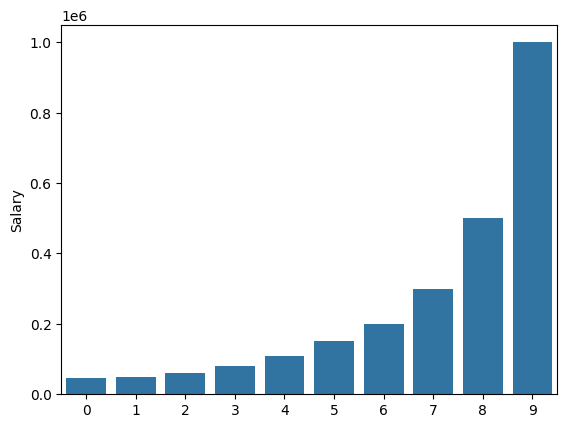

In [117]:
sns.barplot(df['Salary'])


<Axes: >

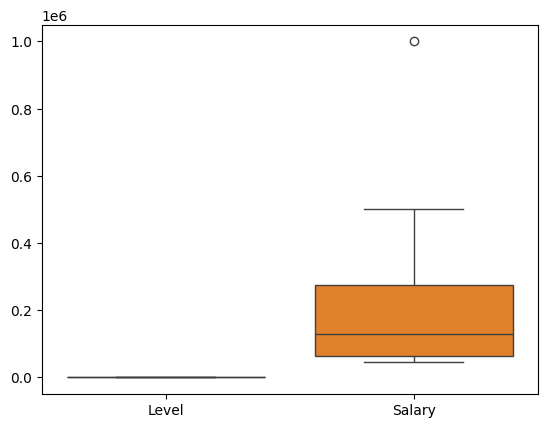

In [118]:
sns.boxplot(df.select_dtypes('number'))


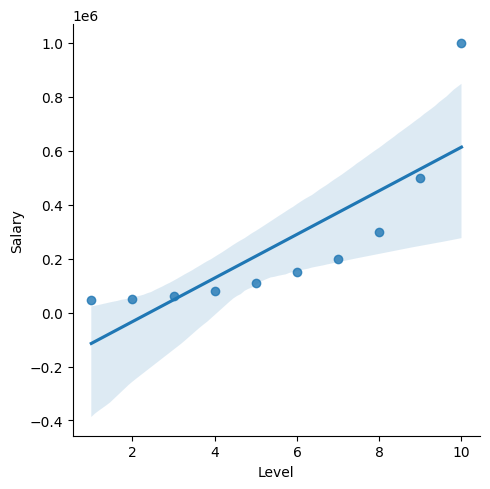

In [119]:
sns.lmplot(x='Level',y='Salary',data=df)


In [120]:
x=df.iloc[:,-2:-1].values
y=df.iloc[:,-1].values

In [121]:

#polinomial regression
from sklearn.preprocessing import PolynomialFeatures
pf=PolynomialFeatures(degree=6)
x_poly=pf.fit_transform(x)

In [122]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_poly,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [123]:

ypred=lr.predict(x_poly)
ypred

array([ 45190.55943885,  49086.82983559,  61383.44988142,  79877.62237539,
       108808.85780717, 149282.05128126, 203940.55944075, 295889.27739067,
       501867.71562081, 999673.0769281 ])

In [124]:
lr.coef_


array([ 0.00000000e+00, -8.29439977e+04,  6.58964015e+04, -2.43819566e+04,
        4.92908654e+03, -4.95432692e+02,  1.97916667e+01])

In [125]:
lr.intercept_


np.float64(82166.666658008)

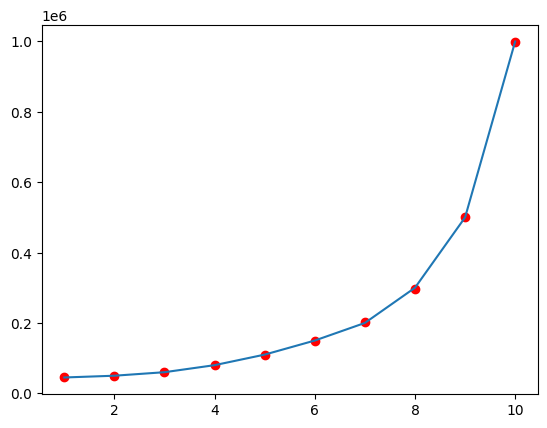

In [126]:
# vosualising
plt.plot(x,y)
plt.scatter(x,ypred,color='red')

In [127]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
print(mean_squared_error(y,ypred))
print(mean_absolute_error(y,ypred))
print(np.sqrt(mean_squared_error(y,ypred)))


4075466.200466927
1476.4568763643576
2018.7783931048318


In [128]:
result=pd.DataFrame(columns=['Actual_salary','Predicted_salary'])
result['Actual_salary']=y
result['Predicted_salary']=ypred
result.reset_index()
result.head()

,Actual_salary,Predicted_salary
0,45000,45190.559439
1,50000,49086.829836
2,60000,61383.449881
3,80000,79877.622375
4,110000,108808.857807


In [129]:
r2_score(y,ypred)

0.9999494749253776